[2024-09-20 15:11:49,434][connect:74] Socket connected


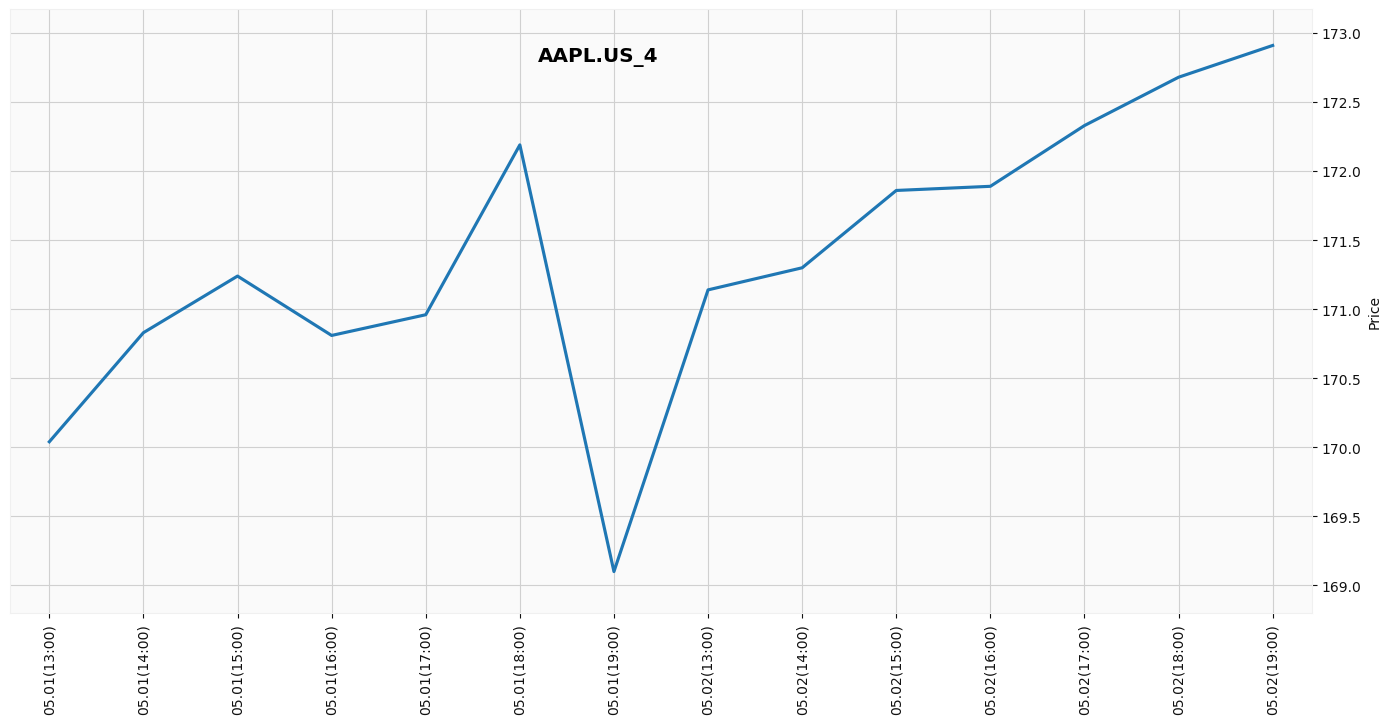

In [1]:
import sys, os, datetime, time, warnings
sys.path.append('../xtb')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
from datetime import datetime
from DataCollectorXtb import DataCollectorXtb 

collector=DataCollectorXtb(symbol='AAPL.US_4', start='2024-05-01', end='2024-05-03', period='1h',
                spread_col=False, cols_to_save=['Date', 'Open', 'High', 'Low', 'Close'])

df = collector.data
#print(df)

title = 'AAPL.US_4'
df.columns = ['Date', 'Open', 'High', 'Low', 'Close']

df.set_index('Date')
df.index = pd.to_datetime(df.Date)

start_date = df['Date'].iloc[0]
end_date = df['Date'].iloc[-1]

fig, axlist= mpf.plot(df,
	style='yahoo', 
	type='line', 
	title=title, 
	volume=False, 
	xrotation=90, 
	ylabel='Price',
	figsize=(15,7), 
	figscale=1,
	returnfig=True,
	tight_layout=True,
	show_nontrading=False,
	#savefig=dict(fname='ohlc_wide_'+sym+'_'+act_int+'.jpg',dpi=125, quality=95, bbox_inches='tight')
)

idx = pd.date_range(start_date, end_date, freq='1h')
df_label_idx = pd.DataFrame(index=idx)

df_label = pd.merge(df_label_idx, df, how='inner', left_index=True, right_index=True )

# Tick labels are generated based on df_label
tick_labels = list(df_label.index.strftime('%m.%d(%H:%M)'))
ticklocations = [df.index.get_loc(tick) for tick in df_label.index ]

axlist[-2].xaxis.set_ticks(ticklocations)
axlist[-2].set_xticklabels(tick_labels)

mpf.show()